In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

In [2]:
data_folder = Path("../data/processed/train_test_w_marine/")

In [3]:
# concatenate all results.json
results_files = data_folder.glob("**/results.json")
results_list = []
for results_file in results_files:
    with open(results_file) as fid:
        results_list.append(json.load(fid))
results = pd.DataFrame(results_list)

In [4]:
results

,feature_name,feature_type,phenotype_name,train_set_id,test_set_id,rep,path,accuracy,balanced_accuracy,matthews_corrcoef
0,kofam,full,Glucose,atleaf+pmi,lit,0,../data/processed/train_test_w_marine/feat(kof...,0.584615,0.421395,-0.187617
1,kofam,full,Glucose,atleaf+pmi,lit,1,../data/processed/train_test_w_marine/feat(kof...,0.630769,0.386792,-0.226415
2,kofam,full,Glucose,atleaf+pmi,lit,2,../data/processed/train_test_w_marine/feat(kof...,0.569231,0.336364,-0.263880
3,kofam,full,Glucose,atleaf+pmi,lit,3,../data/processed/train_test_w_marine/feat(kof...,0.523077,0.389031,-0.210201
4,kofam,full,Glucose,atleaf+pmi,lit,4,../data/processed/train_test_w_marine/feat(kof...,0.492308,0.391844,-0.206981
...,...,...,...,...,...,...,...,...,...,...
1870,kofam,full,Maltose,atleaf,marine,0,../data/processed/train_test_w_marine/feat(kof...,0.735294,0.780632,0.526056
1871,kofam,full,Maltose,atleaf,marine,1,../data/processed/train_test_w_marine/feat(kof...,0.794118,0.800395,0.571090
1872,kofam,full,Maltose,atleaf,marine,2,../data/processed/train_test_w_marine/feat(kof...,0.647059,0.684982,0.369963
1873,kofam,full,Maltose,atleaf,marine,3,../data/processed/train_test_w_marine/feat(kof...,0.764706,0.745833,0.468786


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

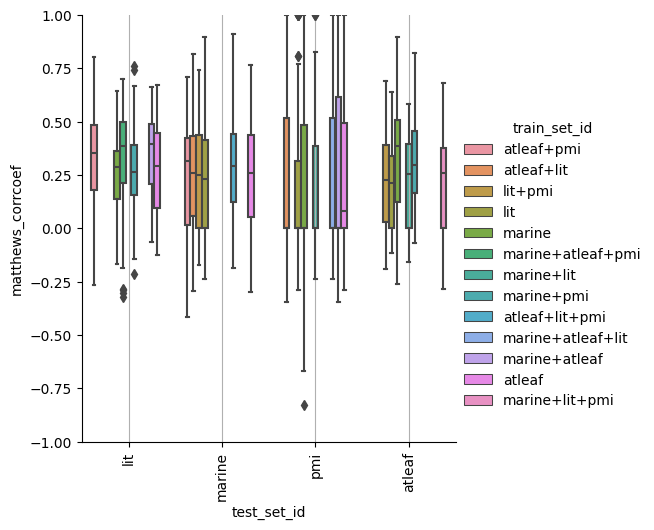

In [6]:
plot_data = results.copy()
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    kind="box",
    hue="train_set_id",
    )
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


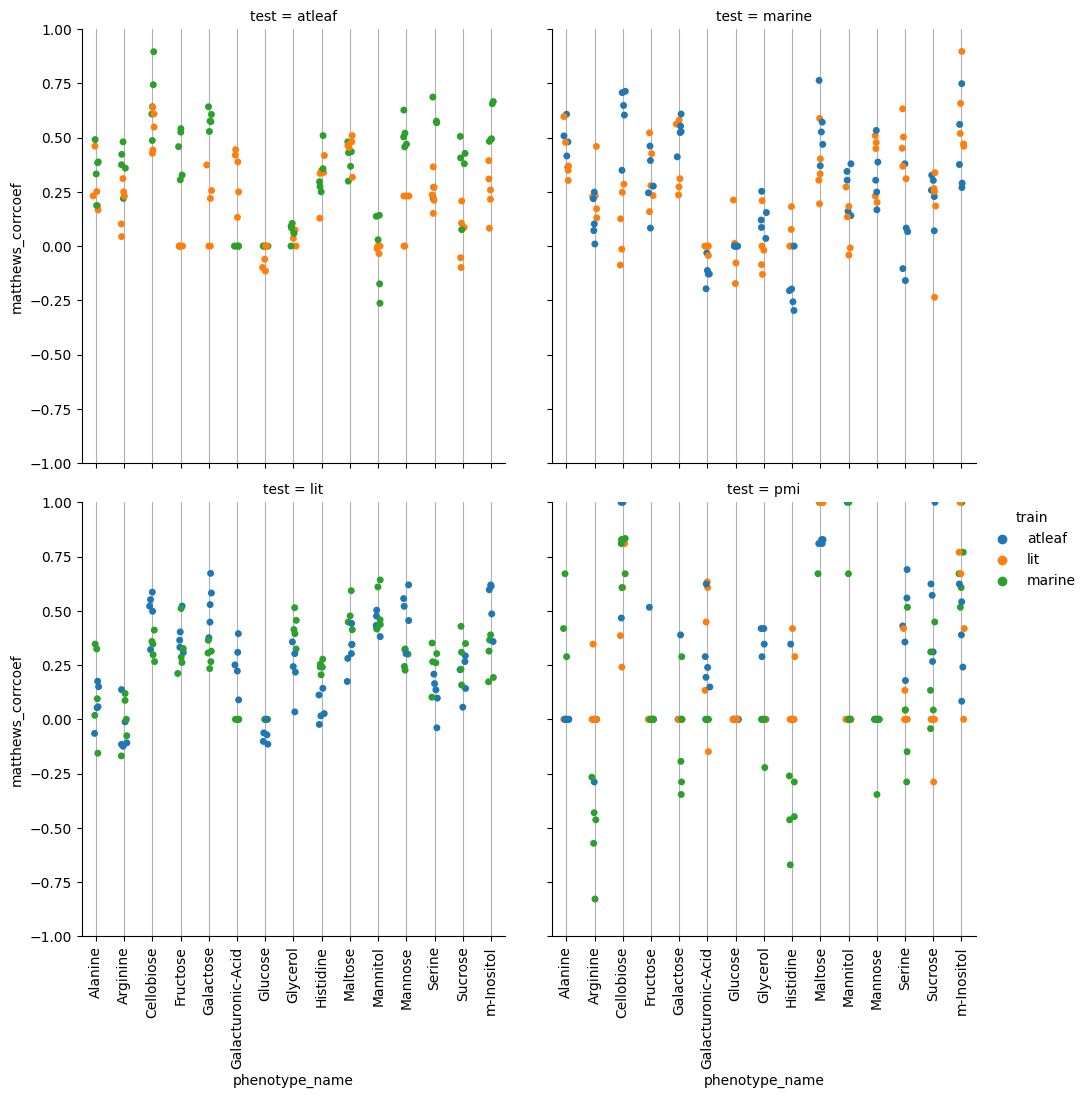

In [12]:
plot_data = results[(results["train_set_id"].isin(["atleaf", "lit", "marine"]))].copy()
plot_data.rename(columns={"train_set_id": "train", "test_set_id": "test"}, inplace=True)
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    kind="strip",
    col="test",
    hue="train",
    col_order=["atleaf", "marine", "lit", "pmi"],
    hue_order=["atleaf", "lit", "marine"],
    col_wrap=2,
    order=sorted(plot_data["phenotype_name"].unique()),
    )
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)